# D: Diamonds

There are no hints and no answers in this lab sheet. Towards the end of the session, we will discuss a solution together - so you can compare yours with the one I will present.

In lab sheet C, I led you by the hand, step-by-step. Here, you're on your own!

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    ShuffleSplit,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import (
    MinMaxScaler,
    RobustScaler,
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error

In [4]:
rng = np.random.RandomState(2)

## The business problem

A diamond merchant finds that her employees are quite inconsistent when pricing the diamonds they buy and sell. Perhaps if there were a pricing tool that they could consult - to get a guideline price - then there would be greater consistency across her employees. She asks you to build the tool. Most important to her is correct pricing - but if the tool can explain its prices, so much the better.

## Performance measures

You realise that this is a regression problem and that mean absolute error (MAE) is the main metric to use in the evaluation. It makes sense to compare against a baseline - a dummy regressor that predicts the mean price of the training examples.

## Dataset

The merchant provides you with a CSV file (`diamonds.csv`), each row of which describes a diamond and its price. (In truth, the dataset comes from [Kaggle](https://www.kaggle.com/datasets/ronil8/diamond-price-prediction-dataset).)

Each row in the CSV file contains 10 pieces of data, which she explains as follows:

- Carat: The carat value of a diamond is a measure of its weight. One carat is 200 milligrams.
- Cut: The cut type of a diamond (Fair, Good, Very Good, Premium, Ideal) is a measure of quality: how it interacts with light.
- Colour: The colour grade of a diamond, in this case from J -> worst to D -> best.
- Clarity: The clarity of a diamond in terms of transparency, in this case from I1 -> worst through SI2, SI1, VS2, VS1, VVS2, VVS1, to IF -> best.
- Depth: The depth of a diamond is calculated as (Height * 200) / (Width + Length). It's a percentage and, apparently, 59-62% is ideal.
- Table: The table of a diamond refers to the flat facet that you can see when you look at the diamond from above. The value recorded here is the width of this facet times 100 divided by the Width of the diamond. Apparently, 53-58% is ideal.
- Price: This is the target value. It is given in US dollars.
- Width: Millimetres.
- Length: Millimetres.
- Height: Millimetres.

In [5]:
import os

if 'google.colab' in str(get_ipython()):
    from google.colab import drive

    drive.mount('/content/drive')
    base_dir = './drive/My Drive/Colab Notebooks/'  # You may need to change this, depending on where your notebooks are on Google Drive
else:
    base_dir = '.'
dataset_dir = os.path.join(base_dir, 'datasets')

In [6]:
df = pd.read_csv(os.path.join(dataset_dir, 'diamonds.csv'))

Now you're on your own. You know the steps: take a cheeky look, clean anything that's invalid, split, EDA, Feature Engineering, Preprocessing, Model Selection and, after any necessary iteration, finally Error Estimation. To speed things along, you can skip EDA.

## Take a cheeky look

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Carat    53940 non-null  float64
 1   Cut      53940 non-null  object 
 2   Colour   53940 non-null  object 
 3   Clarity  53940 non-null  object 
 4   Depth    53940 non-null  float64
 5   Table    53940 non-null  float64
 6   Price    53940 non-null  int64  
 7   Length   53940 non-null  float64
 8   Width    53940 non-null  float64
 9   Height   53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [8]:
df.head()

,Carat,Cut,Colour,Clarity,Depth,Table,Price,Length,Width,Height
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
df.describe()

,Carat,Depth,Table,Price,Length,Width,Height
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [10]:
df.describe()

,Carat,Depth,Table,Price,Length,Width,Height
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [11]:
df['Cut'].unique(), df['Colour'].unique(), df['Clarity'].unique()

(array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object),
 array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object),
 array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
       dtype=object))

In [12]:
df[df.duplicated()]

,Carat,Cut,Colour,Clarity,Depth,Table,Price,Length,Width,Height
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
2025,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
...,...,...,...,...,...,...,...,...,...,...
47969,0.52,Ideal,D,VS2,61.8,55.0,1919,5.19,5.16,3.20
49326,0.51,Ideal,F,VVS2,61.2,56.0,2093,5.17,5.19,3.17
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.00,0.00,0.00
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.19,5.17,3.17


Diamonds with no height, length, and or width.

To encode:
- Cut -> One-hot
- Colour -> One-hot
- Clarity -> One-hot

## Cleanup anything that is simply invalid

In [13]:
df = df[(df['Length'] > 0) & (df['Width'] > 0) & (df['Height'] > 0)]

In [14]:
df.describe(include='all')

,Carat,Cut,Colour,Clarity,Depth,Table,Price,Length,Width,Height
count,53920.000000,53920,53920,53920,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21548,11284,13063,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797698,NaN,NaN,NaN,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,NaN,NaN,NaN,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000


## Split into training set and test set

In [15]:
features = [
    'Carat',
    'Cut',
    'Colour',
    'Clarity',
    'Depth',
    'Table',
    'Length',
    'Width',
    'Height',
]

numeric_features = [
    'Carat',
    'Depth',
    'Table',
    'Length',
    'Width',
    'Height',
]
nominal_features = [
    'Cut',
    'Colour',
    'Clarity',
]

train: pd.DataFrame
test: pd.DataFrame
train, test = train_test_split(df, test_size=0.25, random_state=rng)

train_X: pd.DataFrame = train[features]
train_y: pd.Series = train.Price
test_X: pd.DataFrame = test[features]
test_y: pd.Series = test.Price

##  Exploratory Data Analysis

Skip this step. Otherwise, you won't finish during the lab session.

## Feature Engineering

Don't spend too long on this step - we practised it in the previous lab. 

In [16]:
train_X_copy = train_X.copy()

In [17]:
train_X_copy['Weight'] = 200 * train_X_copy['Carat']

<Axes: >

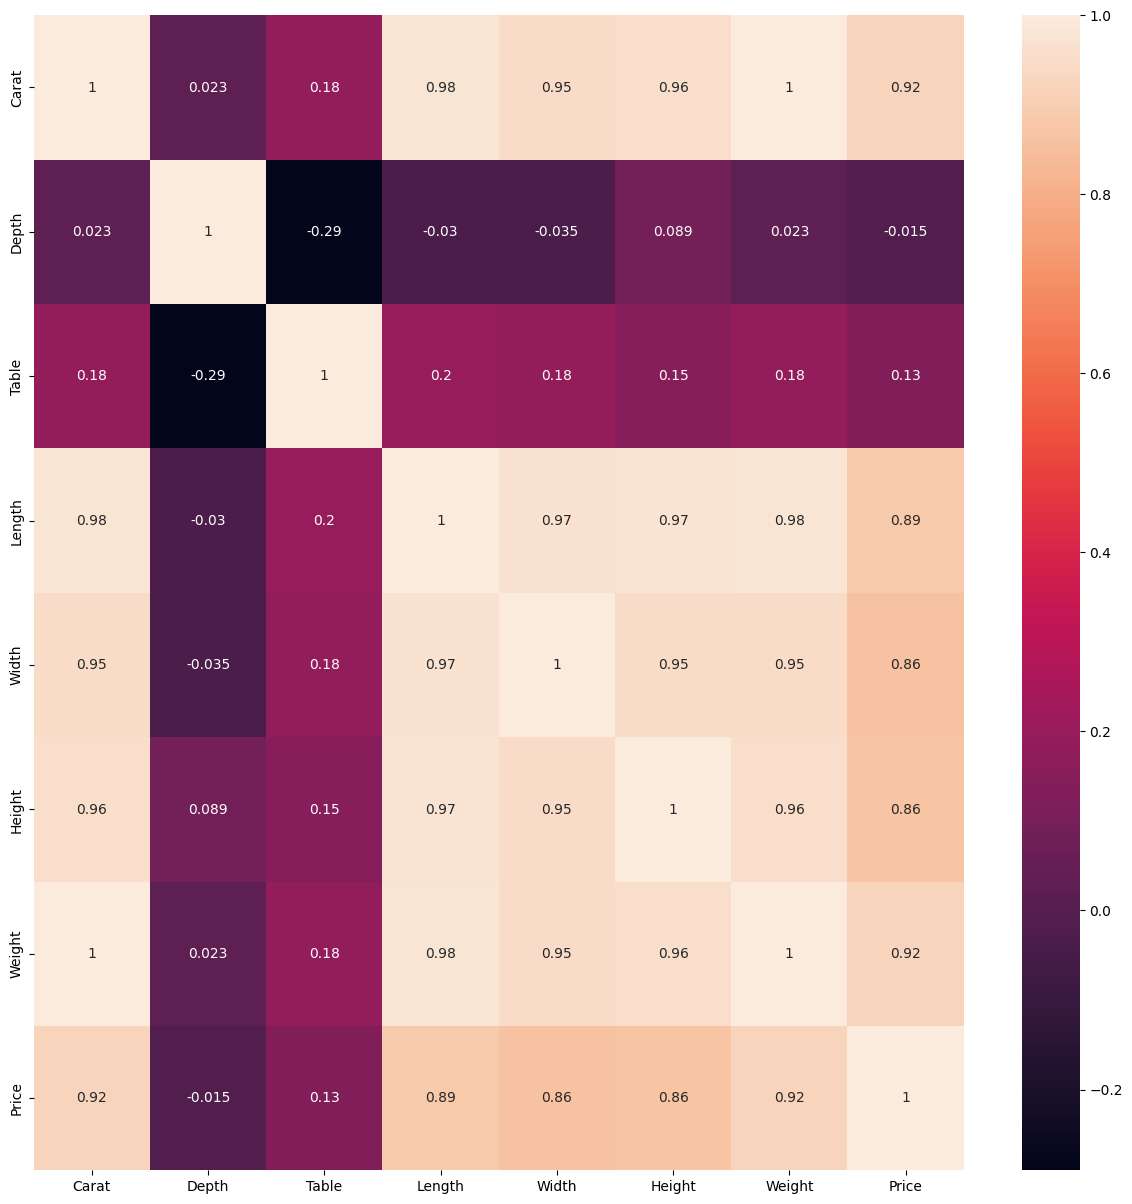

In [18]:
fig_size = (15,) * 2
train_X_corr = train_X_copy.copy()
train_X_corr['Price'] = train_y
sns.heatmap(
    train_X_corr.corr(numeric_only=True),
    annot=True,
    ax=plt.subplots(figsize=fig_size)[1],
)

## Preprocess the Data

### Adding Features

In [19]:
class InsertVolume(BaseEstimator, TransformerMixin):
    def __init__(self, insert=True) -> None:
        self.insert = insert

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.insert:
            X['Volume'] = X['Height'] * X['Length'] * X['Width']
        return X


class InsertDepthWeight(BaseEstimator, TransformerMixin):
    def __init__(self, insert=True) -> None:
        self.insert = insert

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.insert:
            X['Depth Weight'] = X['Depth'] / 60
        return X


class InsertTableWeight(BaseEstimator, TransformerMixin):
    def __init__(self, insert=True) -> None:
        self.insert = insert

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.insert:
            X['Table Weight'] = X['Table'] / 55.5
        return X


class InsertWeight(BaseEstimator, TransformerMixin):
    def __init__(self, insert=True) -> None:
        self.insert = insert

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.insert:
            X['Weight'] = 200 * X['Carat']
        return X

In [20]:
preprocessor = ColumnTransformer(
    [
        (
            'num',
            Pipeline(
                [
                    ('volume', InsertVolume()),
                    ('depth_weight', InsertDepthWeight()),
                    ('table_weight', InsertTableWeight()),
                    ('weight', InsertWeight()),
                    ('scaler', None),
                ]
            ),
            numeric_features,
        ),
        (
            'nom',
            Pipeline([('encoder', None)]),
            nominal_features,
        ),
    ],
    remainder='drop',
)

## Model selection

In [21]:
dummy = DummyRegressor()
dummy.fit(train_X, train_y)

np.mean(
    cross_val_score(dummy, train_X, train_y, scoring='neg_mean_absolute_error', cv=10)
)

np.float64(-3037.5022683224392)

In [22]:
def grid_search(train_X, train_y, preprocessor, predictor, param_grid, cv, metric):
    model = Pipeline([('preprocessor', preprocessor), ('predictor', predictor)])

    gs = GridSearchCV(model, param_grid, scoring=metric, cv=cv, n_jobs=-1)

    gs.fit(train_X, train_y)

    return gs

In [23]:
param_grid = {
    'preprocessor__nom__encoder': [OneHotEncoder(), OrdinalEncoder()],
    'preprocessor__num__volume__insert': [True, False],
    'preprocessor__num__depth_weight__insert': [True, False],
    'preprocessor__num__table_weight__insert': [True, False],
    'preprocessor__num__weight__insert': [True, False],
}

In [24]:
ss = ShuffleSplit(n_splits=1, test_size=0.25, random_state=rng)

In [25]:
dt_gs = grid_search(
    train_X,
    train_y,
    preprocessor=preprocessor,
    predictor=DecisionTreeRegressor(random_state=rng),
    param_grid={
        **param_grid,
        'predictor__max_depth': range(1, 11),
    },
    cv=ss,
    metric='neg_mean_absolute_error',
)

dt_gs.best_params_, dt_gs.best_score_


({'predictor__max_depth': 10,
  'preprocessor__nom__encoder': OrdinalEncoder(),
  'preprocessor__num__depth_weight__insert': True,
  'preprocessor__num__table_weight__insert': True,
  'preprocessor__num__volume__insert': False,
  'preprocessor__num__weight__insert': True},
 np.float64(-348.9719307162601))

In [26]:
knn_gs = grid_search(
    train_X,
    train_y,
    preprocessor=preprocessor,
    predictor=KNeighborsRegressor(),
    param_grid={
        **param_grid,
        'preprocessor__num__scaler': [
            None,
            MinMaxScaler(),
            RobustScaler(),
            StandardScaler(),
        ],
        'predictor__n_neighbors': range(1, 11),
        'predictor__weights': ['uniform', 'distance'],
    },
    cv=ss,
    metric='neg_mean_absolute_error',
)

knn_gs.best_params_, knn_gs.best_score_

({'predictor__n_neighbors': 4,
  'predictor__weights': 'distance',
  'preprocessor__nom__encoder': OrdinalEncoder(),
  'preprocessor__num__depth_weight__insert': False,
  'preprocessor__num__scaler': MinMaxScaler(),
  'preprocessor__num__table_weight__insert': False,
  'preprocessor__num__volume__insert': True,
  'preprocessor__num__weight__insert': True},
 np.float64(-358.5946684655773))

In [27]:
lr_gs = grid_search(
    train_X,
    train_y,
    preprocessor=preprocessor,
    predictor=LinearRegression(),
    param_grid={
        **param_grid,
    },
    cv=ss,
    metric='neg_mean_absolute_error',
)

lr_gs.best_params_, lr_gs.best_score_

({'preprocessor__nom__encoder': OneHotEncoder(),
  'preprocessor__num__depth_weight__insert': True,
  'preprocessor__num__table_weight__insert': True,
  'preprocessor__num__volume__insert': True,
  'preprocessor__num__weight__insert': True},
 np.float64(-739.3212018562102))

## Error Estimation - evaluate on the the test set

In [28]:
mean_absolute_error(dt_gs.best_estimator_.predict(test_X), test_y)

352.78678976426744